In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'




In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [5]:
denman = [99.5, -66.75]
conger = [103,-66]

In [6]:
lwe_ds = GRACE().ds
sla = SLA(deg=1).da
sla0 = SLA(deg=0.25).da
dot_ds = DOT().ds

In [7]:
elevation_ = GEBCO(coarsen_factor=10).ds.elevation
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')


In [8]:
sice = sice.__xarray_dataarray_variable__

In [9]:
data_extent = [98,105,-67,-65]
map_extent = [98,105.5,-67,-64.5]

In [10]:
# crop elevation
elevation = elevation_.sel(latitude = slice(map_extent[2], map_extent[3]), longitude = slice(map_extent[0],map_extent[1]))

In [11]:
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()


sha_ds_dot = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [12]:
meop=MEOP(extent=data_extent)

In [13]:
meop.load_profiles()

  0%|          | 0/108 [00:00<?, ?it/s]

100%|██████████| 108/108 [00:16<00:00,  6.61it/s]


In [14]:
for y in meop.df.index.year.unique():
    print(y)
    print(meop.df[meop.df.index.year==y].groupby(pd.Grouper(freq='MS')).count().sst)

2020
2020-04-01    34
Freq: MS, Name: sst, dtype: int64
2012
2012-02-01     2
2012-03-01     2
2012-04-01     6
2012-05-01    50
2012-06-01     0
2012-07-01     0
2012-08-01     0
2012-09-01     0
2012-10-01    30
2012-11-01     5
Freq: MS, Name: sst, dtype: int64
2013
2013-03-01    45
Freq: MS, Name: sst, dtype: int64
2023
2023-03-01    66
2023-04-01     1
Freq: MS, Name: sst, dtype: int64
2021
2021-02-01    1
Freq: MS, Name: sst, dtype: int64
2004
2004-05-01    34
2004-06-01    80
2004-07-01    40
Freq: MS, Name: sst, dtype: int64
2011
2011-03-01    6
Freq: MS, Name: sst, dtype: int64


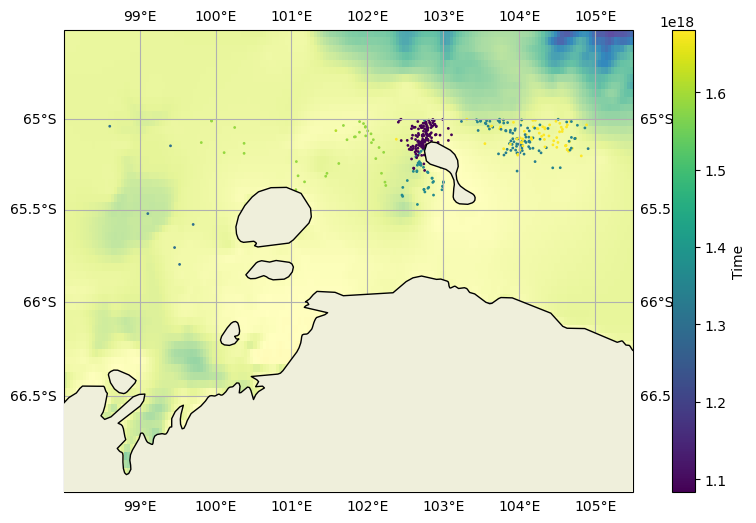

In [15]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax=ax,da=elevation,extent=map_extent)
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')


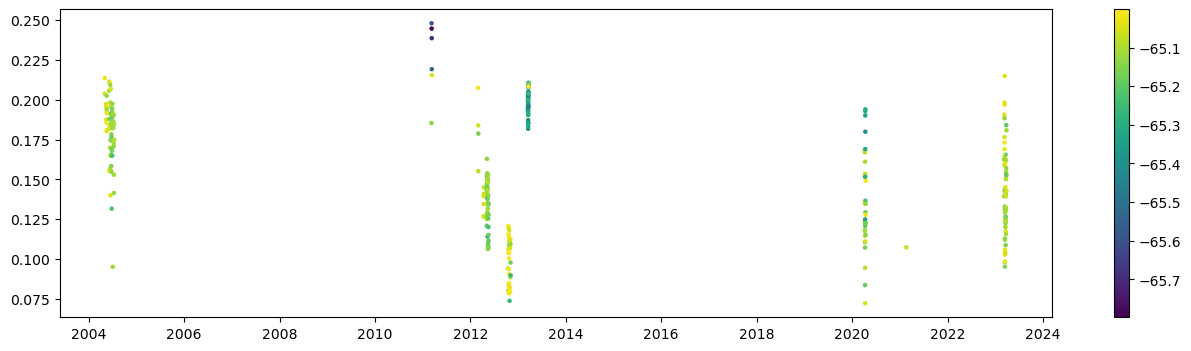

In [16]:
fig, ax = plt.subplots(figsize=(16,4))
img = ax.scatter(meop.df.index,meop.df.gph,5,meop.df.latitude)
cbar = plt.colorbar(img)

In [17]:
# crop datasets to chosen area
extent = data_extent
sla_ = crop_to_extent(sla,extent)
sla0_ = crop_to_extent(sla0,extent)
lwe_ = crop_to_extent(lwe_ds,extent).lwe_thickness
dot_ = crop_to_extent(dot_ds,extent).dota
sha_sla_ = crop_to_extent(sha_ds_sla,extent).sha
sha_dot_ = crop_to_extent(sha_ds_dot,extent).sha
sice_ = crop_to_extent(sice,extent)

(12053.0, 18962.0)

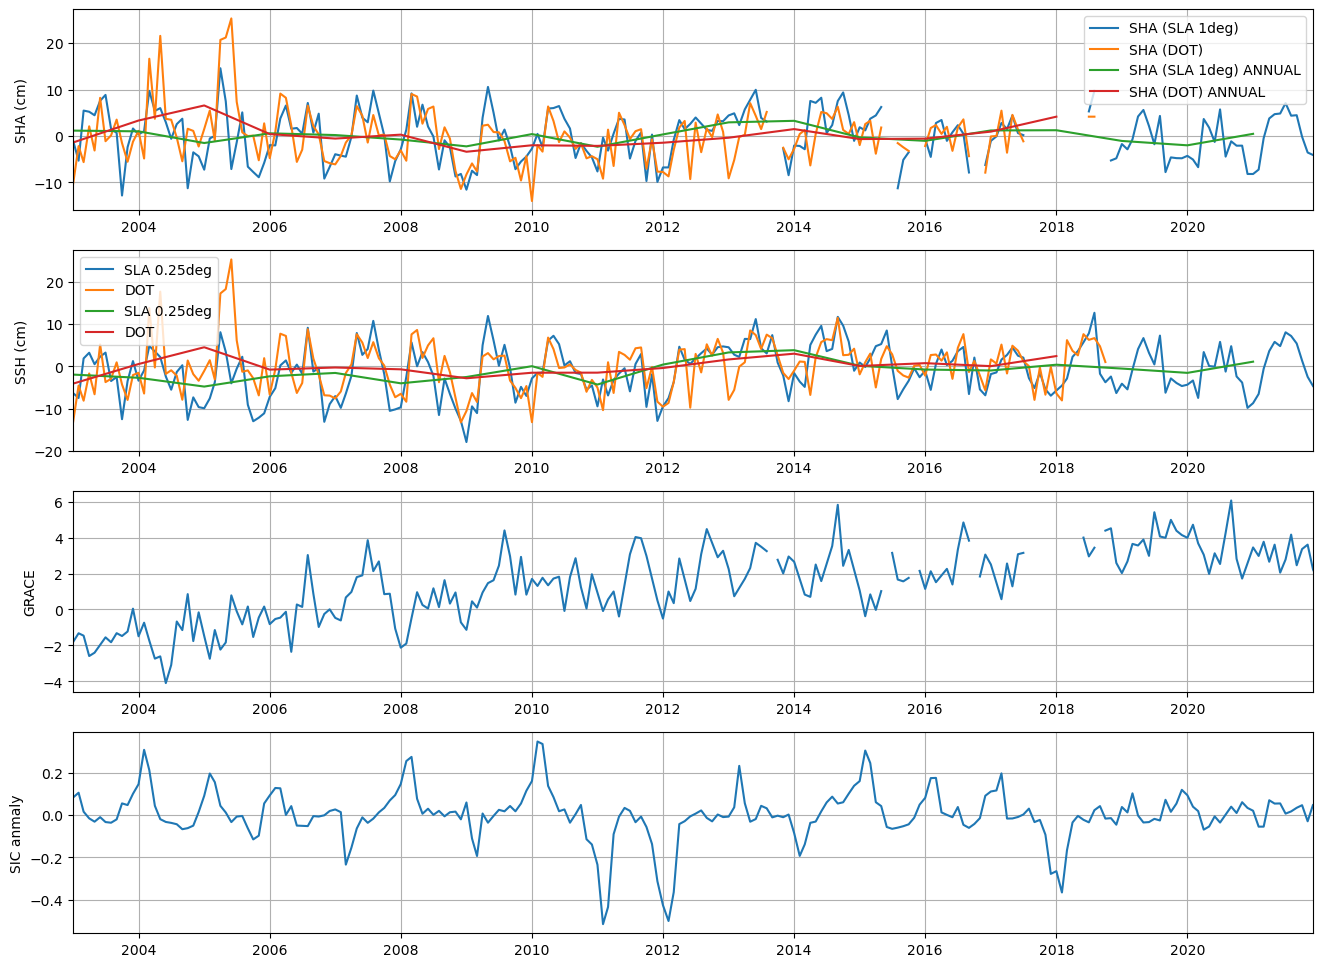

In [18]:
fig,ax = plt.subplots(4,1,figsize=(16,12))
ax[0].plot(sha_sla_.time,sha_sla_.mean(['latitude','longitude']),label='SHA (SLA 1deg)')
ax[0].plot(sha_dot_.time,sha_dot_.mean(['latitude','longitude']),label='SHA (DOT)')
an = lambda da: da.groupby('time.year').mean()
yr = lambda da: [pd.Timestamp(y.item(),1,1) for y in an(da).year]
ax[0].plot(yr(sha_sla_),an(sha_sla_).mean(['latitude','longitude']),label='SHA (SLA 1deg) ANNUAL')
ax[0].plot(yr(sha_dot_),an(sha_dot_).mean(['latitude','longitude']),label='SHA (DOT) ANNUAL')
ax[0].set_ylabel('SHA (cm)')
ax[0].legend(loc='best')
ax[0].grid()
ax[0].set_xlim([sla_.time[0],sla_.time[-1]])
# ax.scatter(meop.df.index,meop.df.gph*100,1,marker='x')
ax[1].plot(sla0_.time,sla0_.mean(['latitude','longitude']),label='SLA 0.25deg')
ax[1].plot(dot_.time,dot_.mean(['latitude','longitude']),label='DOT')
ax[1].plot(yr(sla0_),an(sla0_).mean(['latitude','longitude']),label='SLA 0.25deg')
ax[1].plot(yr(dot_),an(dot_).mean(['latitude','longitude']),label='DOT')
ax[1].set_ylabel('SSH (cm)')
ax[1].legend(loc='best')
ax[1].grid()
ax[1].set_xlim([sla_.time[0],sla_.time[-1]])

ax[2].plot(lwe_.time,lwe_.mean(['latitude','longitude']))
ax[2].set_ylabel('GRACE')
ax[2].grid()
ax[2].set_xlim([sla_.time[0],sla_.time[-1]])

sice_anom = sice_.groupby('time.month') - sice_.groupby('time.month').mean()
ax[3].plot(sice_.time,sice_anom.mean(['latitude','longitude']))
ax[3].set_ylabel('SIC anmaly')
ax[3].grid()
ax[3].set_xlim([sla_.time[0],sla_.time[-1]])



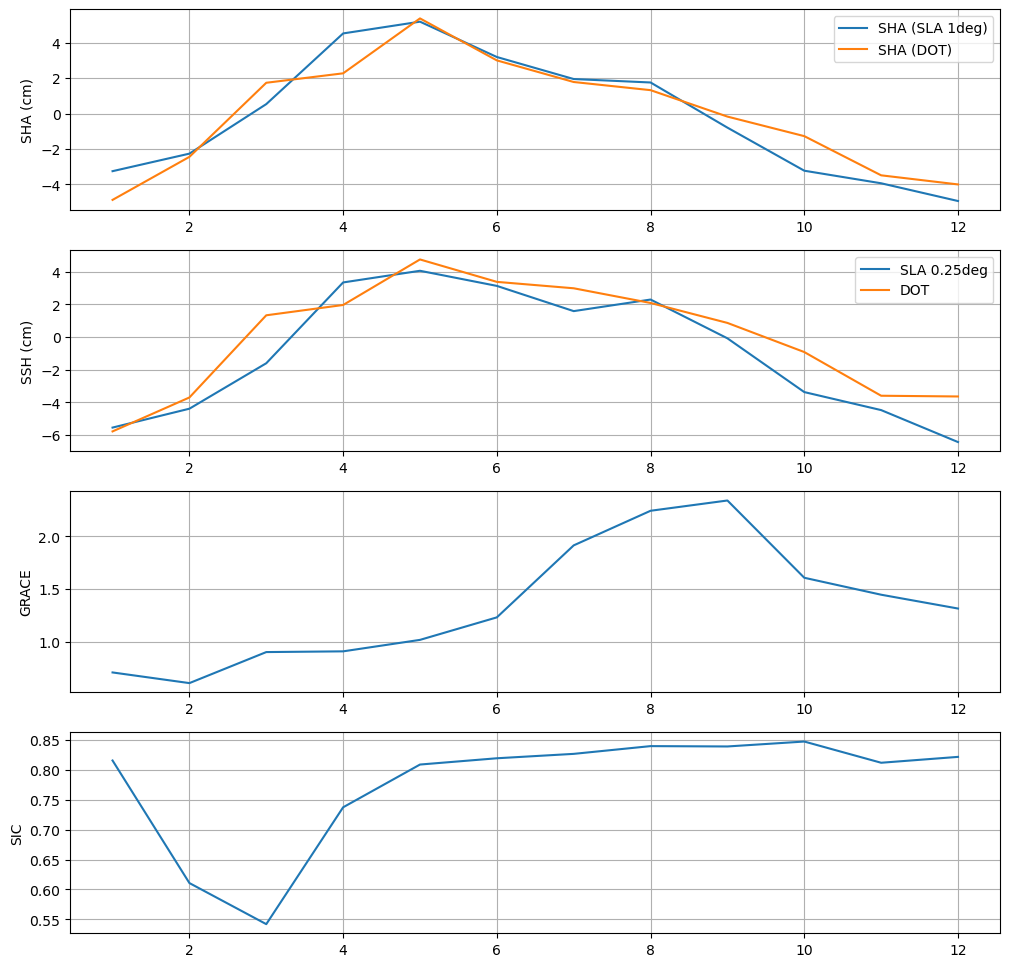

In [20]:
fig,ax = plt.subplots(4,1,figsize=(12,12))

cmt = lambda da: da.groupby('time.month').mean()
months = np.arange(12) + 1

ax[0].plot(months,cmt(sha_sla_).mean(['latitude','longitude']),label='SHA (SLA 1deg)')
ax[0].plot(months,cmt(sha_dot_).mean(['latitude','longitude']),label='SHA (DOT)')
ax[0].set_ylabel('SHA (cm)')
ax[0].legend(loc='best')
ax[0].grid()
# ax.scatter(meop.df.index,meop.df.gph*100,1,marker='x')
ax[1].plot(months,cmt(sla0_).mean(['latitude','longitude']),label='SLA 0.25deg')
ax[1].plot(months,cmt(dot_).mean(['latitude','longitude']),label='DOT')
ax[1].set_ylabel('SSH (cm)')
ax[1].legend(loc='best')
ax[1].grid()

ax[2].plot(months,cmt(lwe_).mean(['latitude','longitude']))
ax[2].set_ylabel('GRACE')
ax[2].grid()

ax[3].plot(months,cmt(sice_).mean(['latitude','longitude']))
ax[3].set_ylabel('SIC')
ax[3].grid()



In [21]:
years = set(sha_sla_.time.dt.year.to_numpy())

In [1]:
fig, ax = plt.subplots(4,int(np.ceil(len(years)/4)),figsize=(18,16), subplot_kw={"projection":ccrs.Mercator()})

pfsp = lambda ax, yr: pfns.sp(ax,seasonal_anomaly(sla0_).sel(time=slice(pd.Timestamp(yr,5,1),pd.Timestamp(yr,5,28))).mean('time'),title=yr,extent=map_extent,cbar="SHA/cm",vmax=4,cbar_orientation='horizontal',land_zorder=2)

ax=ax.flat
for i,y in enumerate(set(sla0_.time.dt.year.to_numpy())):
    # idx = (np.equal(years,y))
    # for profile in list(compress(profiles,idx)):
    #     ax[i].set_title(str(y))
    pfsp(ax[i],y)
    ax[i].text(denman[0],denman[1],'denman',transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))
    ax[i].text(conger[0],conger[1],'conger',transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))




NameError: name 'plt' is not defined

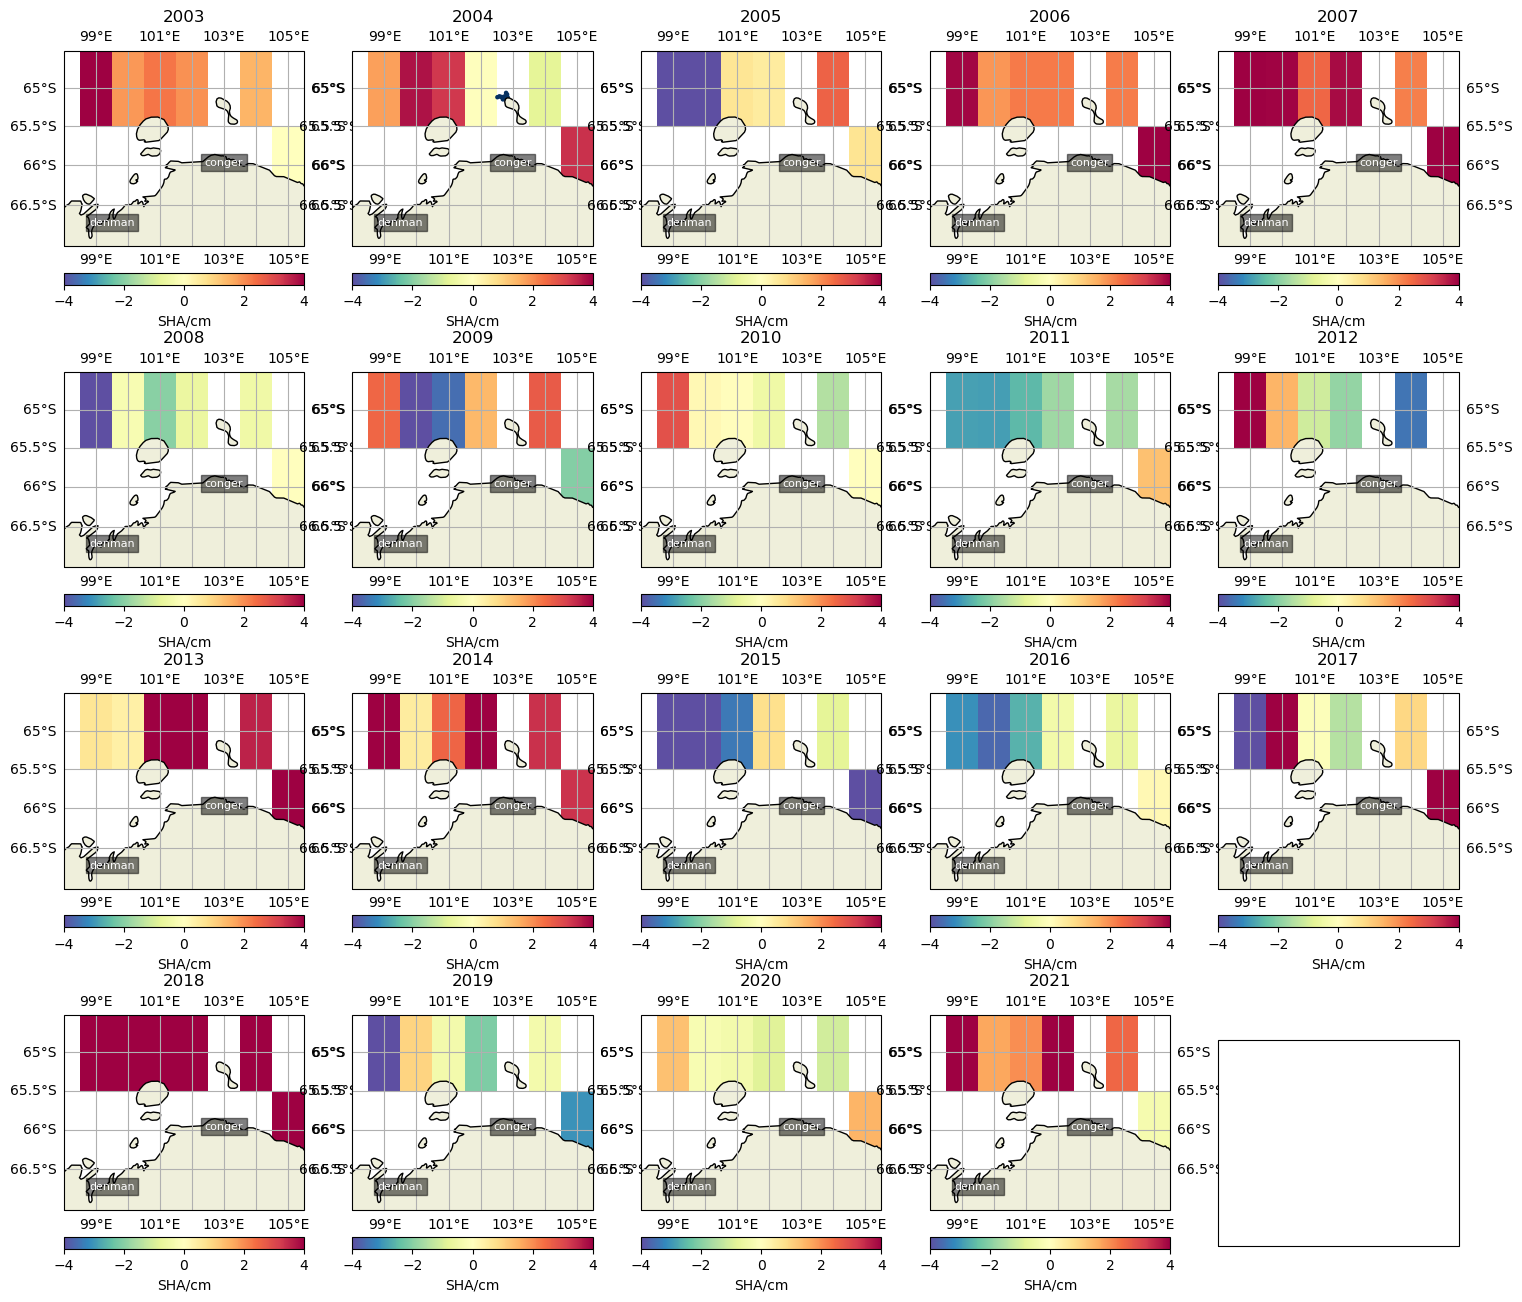

In [27]:
fig, ax = plt.subplots(4,int(np.ceil(len(years)/4)),figsize=(18,16), subplot_kw={"projection":ccrs.Mercator()})
pfsp = lambda ax, yr: pfns.sp(ax,sha_sla_.sel(time=slice(pd.Timestamp(yr,7,1),pd.Timestamp(yr,9,30))).mean('time'),title=yr,extent=map_extent,cbar="SHA/cm",vmax=4,cbar_orientation='horizontal',land_zorder=2)

ax=ax.flat
for i,y in enumerate(set(sha_sla_.time.dt.year.to_numpy())):
    # idx = (np.equal(years,y))
    # for profile in list(compress(profiles,idx)):
    #     ax[i].set_title(str(y))
    pfsp(ax[i],y)
    ax[i].text(denman[0],denman[1],'denman',transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))
    ax[i].text(conger[0],conger[1],'conger',transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))

    df_y = meop.df[(meop.df.index.month > 6) & (meop.df.index.month < 10) & (meop.df.index.year==y)]
    ax[i].scatter(df_y.longitude,df_y.latitude,5,df_y.gph*100,vmax=10,vmin=0,cmap='RdBu',transform=ccrs.PlateCarree())



